# Handling Class Imbalance

Datasets can come with a degree of class imbalance. This is where the interesting class is in the minority by a large margin. You might have 90% of one class and only 10% of instances are of the class you are interested in. This tutorial explains how class imbalance can be handled.

## 1 Visualisng imbalanced datasets

We will use synthetic datasets in this tutorial. So let's first declare and visualise a dataset. Our dataset has only 2 features for ease of visualisation, but any dataset can be reduced to 2 features using principal component analysis. Our dataset has 10000 samples, which is more than enough to resample. We use a random_state so that the same dataset is always generated. Our random_state happens to generate a dataset where there is quite a lot of overlap between the two classes, but selecting a different random_state (e.g. 18 or 42 or 123) gives different datasets with different degrees of overlap. Sometimes class overlap can be more of a problem than class imbalance, so it is worth visualising your dataset like this so you can determine whether class overlap or class imbalance is the greater problem.

,feature1,feature2,class
0,1.028469,1.154931,0
1,0.878099,0.895511,0
2,0.959288,1.039673,0
3,0.855405,0.918473,0
4,1.020339,0.901375,0
...,...,...,...
95,0.751481,1.067029,0
96,0.719879,0.866941,0
97,1.070181,1.491699,0
98,0.850638,0.446895,0


<Axes: xlabel='feature1', ylabel='feature2'>

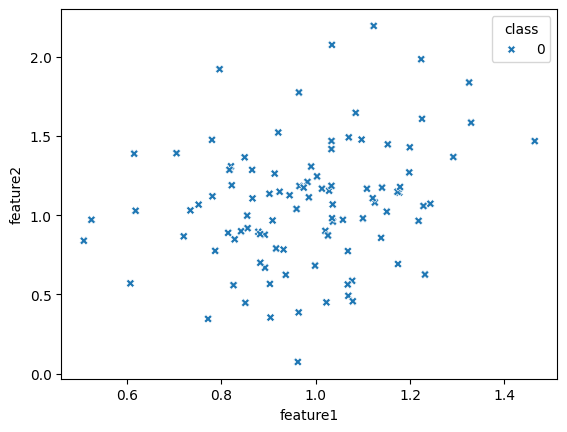

In [3]:
from sklearn.datasets import make_classification
import pandas as pd
import seaborn as sns

# define dataset (remember, we already have X and y...or can generate them quickly with the random_state)
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, weights=[0.999], flip_y=0, random_state=1)

#combine into a pandas dataframe
my_df = pd.DataFrame({'feature1':X[:, 0], 'feature2':X[:, 1], 'class':y})
my_df.to_csv("synthetic_imbalance_3.csv")
display(my_df)

markers = {0: "X", 1: "s"}
sns.scatterplot(data=my_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

The problem with the above plot is that plots the data in order and the majority class is so dense that you cannot always see the minority class points. We can use seaborn's rel plot to make two comparable plots.

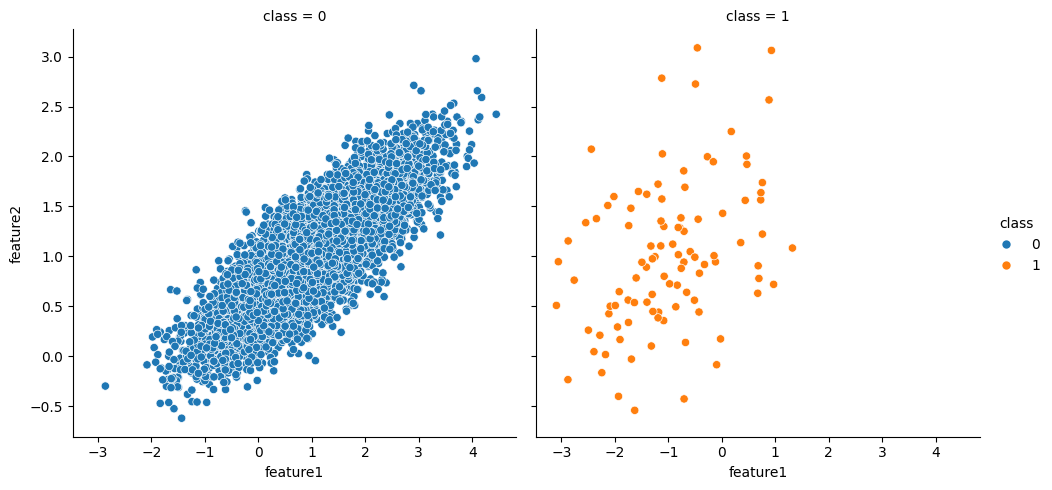

In [55]:
sns.relplot(
    data=my_df, x="feature1", y="feature2",
    col="class", hue="class", 
    kind="scatter"
)

And a countplot to demonstrate the dataset imbalance

<Axes: xlabel='class', ylabel='count'>

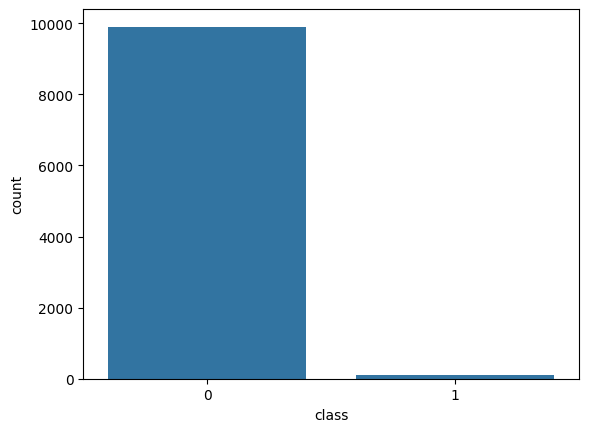

In [56]:
sns.countplot(x="class", data=my_df)


We'll "quickly" train a decision tree classifier to see how well it performs (from Week 5).

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


# Putting the decision tree training and testing into a function here.
def train_decision_tree_and_report(X_train, y_train, X_test, y_test):
    # build a tree
    clf = DecisionTreeClassifier(max_depth = 2, random_state = 0)
    clf.fit(X_train,y_train)

    # evaluate on test set and report metrics
    predictions = clf.predict(X_test)
    accuracy = clf.score(X_test, y_test)
    print(f'The Model Accuracy is {round(accuracy*100,2)}%')
    # But recall accuracy isn't the best metric for imbalanced datasets
    print(confusion_matrix(y_test,predictions))
    print(classification_report(y_test, predictions))

# split dataframe into test and train
X = my_df[["feature1", "feature2"]] ## apologies, we now have X and y for features and label
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)    
train_decision_tree_and_report(X_train, y_train, X_test, y_test)


The Model Accuracy is 98.95%
[[1973    2]
 [  19    6]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1975
           1       0.75      0.24      0.36        25

    accuracy                           0.99      2000
   macro avg       0.87      0.62      0.68      2000
weighted avg       0.99      0.99      0.99      2000



The accuracy is, apparently, not too bad, but the confusion matrix shows that there is some confusion regarding class 1, and the classification report shows that of 25 class-1 instances, we only got 6 of them correct and 19 were classified as class-0 (the majority class). Yes, it is a fairly tiny decision tree with a maximum depth of only 2 (we could increase this at the risk of overfitting).

**Note** how, although the confusion matrix is confusing (are the predictions on the rows or on the columns??), the classification report clarifies that by telling you the support for each class in the test set (i.e. how many instances of each class there are). The rows in the confusion matrix add up to the support, so the rows represent the true class, and the columns are the predictions.

 Let's see if we can improve the classifier's performance.

Now to create an undersampled dataframe just by using a random undersampling method. We assume that the data is already randomly ordered, we sort it according to class (descending because the minority class is class 1) and then we simply take a subsample of the ordered dataset:

,feature1,feature2,class
7984,-0.503037,0.991027,1
1811,-2.343515,1.376700,1
7356,-0.656296,0.638950,1
8322,-0.689079,1.691513,1
6502,0.177632,2.249640,1
...,...,...,...
6617,1.787831,1.527349,0
6670,-0.373033,0.719688,0
6669,1.001231,0.595257,0
6668,1.113437,1.128683,0


<Axes: xlabel='feature1', ylabel='feature2'>

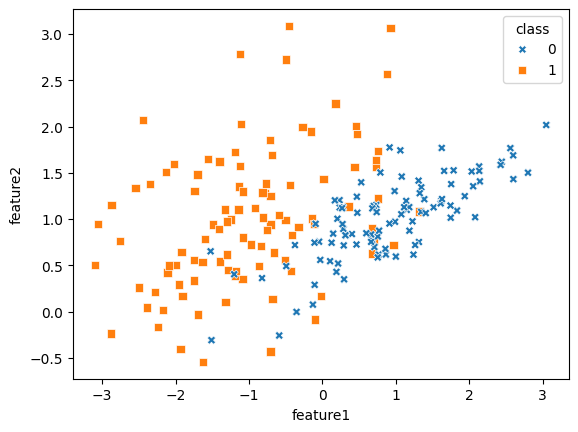

In [60]:
sorted_df = my_df.sort_values(by=['class'], ascending=False)
#display(sorted_df)

random_undersampled_df = sorted_df.head(200)
display(random_undersampled_df)
sns.scatterplot(data=random_undersampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

And a count plot to show the dataset balance:

<Axes: xlabel='class', ylabel='count'>

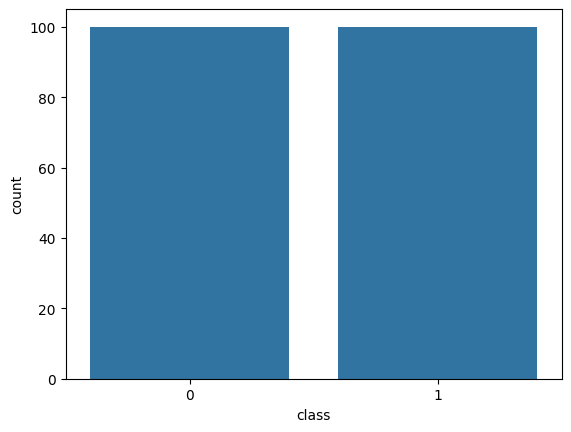

In [61]:
sns.countplot(x="class", data=random_undersampled_df)

Now to use our function and see our new decision tree.

In [69]:
# split dataframe into test and train
X = random_undersampled_df[["feature1", "feature2"]]
y = random_undersampled_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)
train_decision_tree_and_report(X_train, y_train, X_test, y_test)

The Model Accuracy is 85.0%
[[15  2]
 [ 4 19]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        17
           1       0.90      0.83      0.86        23

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.86      0.85      0.85        40



Now we have roughly equal instances of the classes, our performance on class-1 is very much improved. The overall accuracy has also dropped, however. But can we believe it? We'd have to draw a number of random samples and train a few classifiers to truly believe that our model is actually better than that trained on the imbalanced dataset, but it does now look like the decision tree can cope with our minority class.

Let's try a different method of undersampling. We need to use `imblearn` to do this, so import it and check that it's installed.

In [ ]:
# Uncomment the next line if you need to install imblearn
# !pip install imblearn
import imblearn


We're going to use Near Miss undersampling. In `imblearn`:

- NearMiss-1: Majority class examples with minimum average distance to three closest minority class examples.
- NearMiss-2: Majority class examples with minimum average distance to three furthest minority class examples.
- NearMiss-3: Majority class examples with minimum distance to each minority class example.

     feature1  feature2
0   -1.255052  0.406353
1   -1.325066  0.566976
2   -0.174453  0.950820
3   -0.173347  0.945823
4   -1.140191  0.471450
..        ...       ...
145 -1.493112  0.940125
146  0.016794  1.430473
147  0.672733  0.629470
148 -0.117479  0.944178
149 -2.086285  0.499809

[150 rows x 2 columns]


<Axes: xlabel='feature1', ylabel='feature2'>

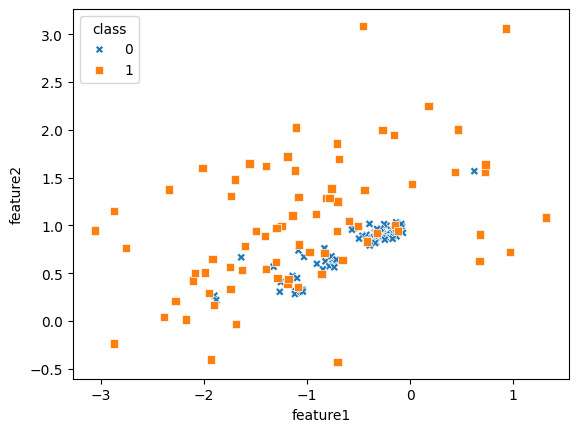

In [80]:
from imblearn.under_sampling import NearMiss
# define the undersampling method
undersample = NearMiss(version=1)

# split dataframe into test and train
X = my_df[["feature1", "feature2"]]
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# We're now going to undersample only on the training set.
X_train_resample, y_train_resample = undersample.fit_resample(X_train, y_train)

print(X_train_resample)


# Plot the resampled data to see what it looks like (use replot because it was easier to understand)
resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)



In [73]:
# train the classifier and report
train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)

The Model Accuracy is 53.95%
[[1062  913]
 [   8   17]]
              precision    recall  f1-score   support

           0       0.99      0.54      0.70      1975
           1       0.02      0.68      0.04        25

    accuracy                           0.54      2000
   macro avg       0.51      0.61      0.37      2000
weighted avg       0.98      0.54      0.69      2000



This gives us a much better overview of how our undersampled classifier performs on our imbalanced test set and is much more comparable to the model trained on the original classifier. You can see that this decision tree has higher precision on class-1 (the minority class), but it also gets a lot more class-0 instances incorrect. This is the trade-off we must sometimes live with when dealing with imbalanced data. In the case of our synthetic dataset with only 2 columns and a not-easily-separable distribution, it might be a permanent trade-off. The accuracy is pretty horrible, though - reporting that level of accuracy implies that you almost might as well flip a coin.

You can adjust the above code to try 

imblearn comes with a number of other undersampling methods:

- `CondensedNearestNeighbour(n_neighbors=)` with [academic article available here](https://ieeexplore.ieee.org/document/1054155). You need to select a number of nearest neighbours to sample from. Instances are selected from the majority class based on how close they are to minority class instances. This form of undersampling focusses the dataset on the decision boundary.
-  `TomekLinks()` with [Tomek's paper on it available here](https://ieeexplore.ieee.org/document/4309452). This form of undersampling reduces the number of instances in the majority class by removing those instances which are the closest nearest neighbour of a member of the minority class (and the closest nearest neighbour relationship is reciprocated).

- See [Brownlee's machine learning mastery tutorial](https://machinelearningmastery.com/undersampling-algorithms-for-imbalanced-classification/) for more examples



The Model Accuracy is 95.8%
[[1906   69]
 [  15   10]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1975
           1       0.13      0.40      0.19        25

    accuracy                           0.96      2000
   macro avg       0.56      0.68      0.59      2000
weighted avg       0.98      0.96      0.97      2000



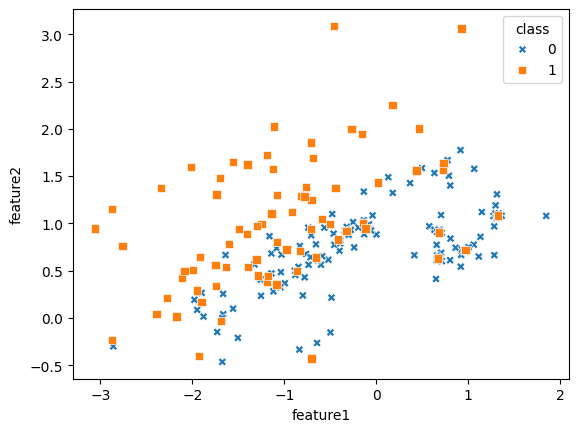

In [81]:
from imblearn.under_sampling import CondensedNearestNeighbour
# define the undersampling method
undersample = CondensedNearestNeighbour(n_neighbors=1)

# split dataframe into test and train
X = my_df[["feature1", "feature2"]]
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# We're now going to undersample only on the training set.
X_train_resample, y_train_resample = undersample.fit_resample(X_train, y_train)

# Plot the resampled data to see what it looks like (use replot because it was easier to understand)
resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

# train the classifier and report
train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)

As can be seen from using CondensedNearestNeighbour resampling, class-0, the majority class, is sampled close to the minority class, focussing the selected points on the overlap of the two classes. The accuracy much better than the NearMiss undersampling, and our model's accuracy looks better again, but precision and recall have dropped for the minority class.

We can try combining CondensedNearestNeighbour with TomekLinks to make sure NearestNeighbour has not added any ambiguous instances to our resampled majority class. Other resampling methods can be combined like this, but resampling should apply only to the training set. If resampling is applied to the test set, you will get an overly optimistic idea of the model's performance on the real world data distribution.



The Model Accuracy is 95.8%
[[1906   69]
 [  15   10]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1975
           1       0.13      0.40      0.19        25

    accuracy                           0.96      2000
   macro avg       0.56      0.68      0.59      2000
weighted avg       0.98      0.96      0.97      2000



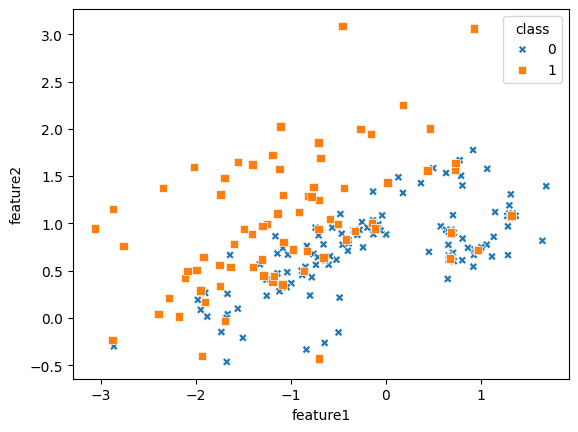

In [84]:
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
# define the undersampling method - condensed nearest neighbour first, followed by Tomek links to remove any ambiguous datapoints.
undersample = CondensedNearestNeighbour(n_neighbors=1)
undersample2 = TomekLinks()

# split dataframe into test and train
X = my_df[["feature1", "feature2"]]
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# We're now going to undersample only on the training set.
X_train_resample_1, y_train_resample_1 = undersample.fit_resample(X_train, y_train)
X_train_resample, y_train_resample = undersample.fit_resample(X_train_resample_1, y_train_resample_1)

# Plot the resampled data to see what it looks like (use replot because it was easier to understand)
resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

# train the classifier and report
train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)

TomekLings has not improved our classifier in this case, but the story could be different with a different dataset distribution.

## 2: Oversampling

Instead of sub-sampling or removing instances of the majority class, we can instead increase the number of samples of the minority class. This is called oversampling.
The simplest method of oversampling is simply random oversampling and this is illustrated in the code below:

The Model Accuracy is 85.75%
[[1697  278]
 [   7   18]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1975
           1       0.06      0.72      0.11        25

    accuracy                           0.86      2000
   macro avg       0.53      0.79      0.52      2000
weighted avg       0.98      0.86      0.91      2000



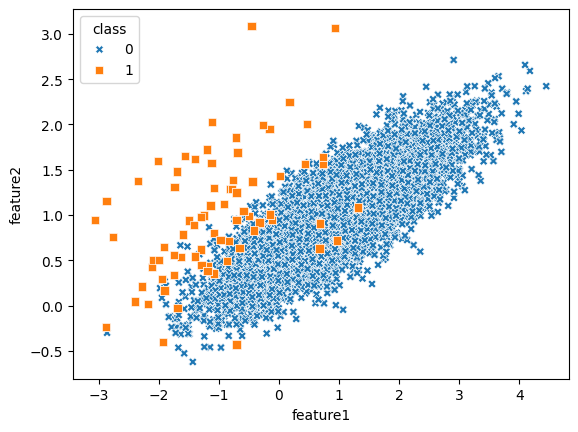

In [ ]:
from imblearn.over_sampling import RandomOverSampler
# define the random oversampling method
oversample = RandomOverSampler(random_state=42)

# split dataframe into test and train
X = my_df[["feature1", "feature2"]]
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# We're now going to oversample only on the training set.
X_train_resample, y_train_resample = oversample.fit_resample(X_train, y_train)

# Plot the resampled data to see what it looks like 
resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

# train the classifier and report
train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)

Random oversampling has worked better than random undersampling, with the model now getting 18 out of 25 class-1 instances correct. It comes at the expense of getting 278 class-0 instances incorrect, but this is lower than the 913 instances we had incorrect in our previous model with highest class-1 recall.

The last method of oversampling is called SMOTE: Synthetic Minority Oversampling TEchnique. This produces synthetic datapoints for the minority class. `imblearn` has a number of different variations on synthetic instance production. See [the imblearn documentation](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) for further details.

The code below applies SMOTE to our dataset and tests it against a DecisionTree in the same way as the above.

The Model Accuracy is 91.0%
[[1803  172]
 [   8   17]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1975
           1       0.09      0.68      0.16        25

    accuracy                           0.91      2000
   macro avg       0.54      0.80      0.56      2000
weighted avg       0.98      0.91      0.94      2000



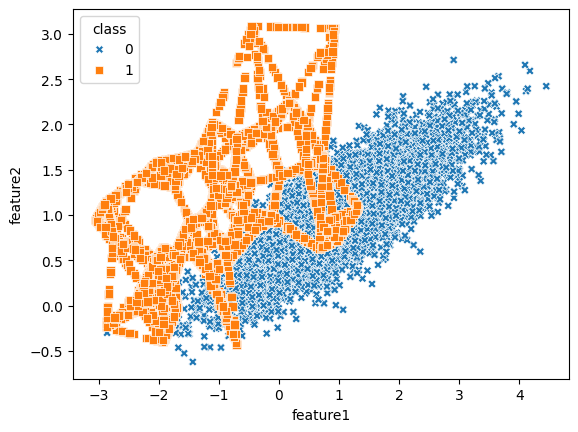

In [ ]:
from imblearn.over_sampling import SMOTE
# define the oversampling method
oversample = SMOTE(random_state=42)

# split dataframe into test and train
X = my_df[["feature1", "feature2"]]
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# We're now going to oversample only on the training set.
X_train_resample, y_train_resample = oversample.fit_resample(X_train, y_train)

# Plot the resampled data to see what it looks like 
resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

# train the classifier and report
train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)

You can see from the plot that SMOTE massively increases the number of minority class instances, but the scatterplot shows that they are not random and they are distinct from the authentic instances. The classifier is one of the better ones, maintaining excellent precision and recall on the majority class while giving reasonable performance in the minority class (recall close to 70%). It still has 172 false positives (majority class instances misclassified as minority class), but the trade-off is substantially less than in the other models.

There is one final flavour of SMOTE that we will try in this tutorial and that is `KMeansSMOTE` a more recent technique described in [a paper available on ArXiV](https://arxiv.org/abs/1711.00837). 

The Model Accuracy is 99.1%
[[1973    2]
 [  16    9]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1975
           1       0.82      0.36      0.50        25

    accuracy                           0.99      2000
   macro avg       0.91      0.68      0.75      2000
weighted avg       0.99      0.99      0.99      2000



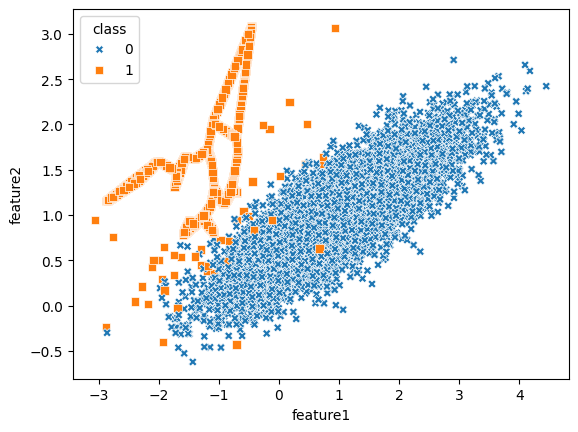

In [105]:
from imblearn.over_sampling import KMeansSMOTE
from sklearn.cluster import MiniBatchKMeans
# define the oversampling method
oversample = KMeansSMOTE(
    kmeans_estimator=MiniBatchKMeans(n_clusters=16, n_init=1, random_state=0), random_state=42
)

# split dataframe into test and train
X = my_df[["feature1", "feature2"]]
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

# We're now going to oversample
X_train_resample, y_train_resample = oversample.fit_resample(X_train, y_train)

# Plot the resampled data
resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

# train the classifier and report
train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)

This method of oversampling the minority class reduces the number of false positives that the classifier can get, but again it is at the expense of the number of true positives. The number of clusters must be set as a parameter and it cannot be lower than 16. Raising it further decreases the performance of the classifier on the training set.

# Low effort code structure: Make the computer do the work

By this stage in time, you should be used to seeing the same few lines of code to resample the dataset (over sampling or undersampling) and to visualise the resampled dataset. You could put a variety of different resampling methods into a for-loop and train and test a classifier to obtain the best resampling parameters for an imbalanced dataset, as shown below.

As an exercise, you could expand this to include different types of classifier by modifying the `train_decision_tree_and_report()` function defined above.

Efficient software structure minimises the number of lines of code that a human has to maintain while maximising the work that the computer does. Defining re-usable functions takes a little effort now in order to save effort later when you can re-use a function rather than writing it again from scratch, or where you fix 1 error in the code and it fixes the error in multiple experimental results.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
def resample_and_train(my_df, features, label, sampler):
    X = my_df[features]
    y = my_df[label]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

    # We're now going to oversample
    X_train_resample, y_train_resample = sampler.fit_resample(X_train, y_train)

    # Plot the resampled data
    resampled_df = pd.DataFrame({'feature1':X_train_resample["feature1"], 'feature2':X_train_resample["feature2"], 'class':y_train_resample})
    ### Plotting will make a big long list of output with lots of scrolling, but you can add it if you want to see the dataset distribution
    #sns.scatterplot(data=resampled_df, x="feature1", y="feature2", hue="class", style='class', markers=markers)

    # train the classifier and report
    train_decision_tree_and_report(X_train_resample, y_train_resample, X_test, y_test)


sampling_methods = [
    [RandomUnderSampler(random_state=42), "random under sampler"],
    [RandomOverSampler(random_state=42), "random over sampling"],
    [SMOTE(random_state=42), "SMOTE"],
    [KMeansSMOTE(kmeans_estimator=MiniBatchKMeans(n_clusters=16, n_init=1, random_state=0), random_state=42), "KmeansSMOTE"],
    # ... extend as required so you can see all the different sampling methods combined.
    
]
features= ["feature1", "feature2"]
label = 'class'

for sampling_method in sampling_methods:
    print("Sampling method: {}".format(sampling_method[1]))
    resample_and_train(my_df, features, label, sampling_method[0])

Sampling method: random under sampler
The Model Accuracy is 83.85%
[[1658  317]
 [   6   19]]
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      1975
           1       0.06      0.76      0.11        25

    accuracy                           0.84      2000
   macro avg       0.53      0.80      0.51      2000
weighted avg       0.98      0.84      0.90      2000

Sampling method: random over sampling
The Model Accuracy is 85.75%
[[1697  278]
 [   7   18]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1975
           1       0.06      0.72      0.11        25

    accuracy                           0.86      2000
   macro avg       0.53      0.79      0.52      2000
weighted avg       0.98      0.86      0.91      2000

Sampling method: SMOTE
The Model Accuracy is 91.0%
[[1803  172]
 [   8   17]]
              precision    recall  f1-score   support

           0       1.00  

# Using class_weights in `Scikit-learn`

Some of the classifiers available through  `scikit-learn` have a parameter called class_weights. Using it will apply class_weights to the classifier and might handle class imbalance without the need for dataset resampling.

The code below trains a decision tree using class_weights on our imbalanced dataset. The key word "balanced" automatically balances the classes according to the distribution of samples in the dataset. 

You can compare the results with the other classifiers above.

In [121]:
# split dataframe into test and train
X = my_df[["feature1", "feature2"]] ## apologies, we now have X and y for features and label
y = my_df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)  

# define some class_weights, remember, class 0 is 90%, class 1 is only 10% of the dataset

class_weights={0: 1, 1:500} # Making class-1 20-times more important than class-0
class_weights={0: 1, 1:100} # Making class-1 20-times more important than class-0
class_weights="balanced" # let the function find out the weights

# build a tree
clf = DecisionTreeClassifier(max_depth = 2, random_state = 0, class_weight=class_weights)
clf.fit(X_train,y_train)

# evaluate on test set and report metrics
predictions = clf.predict(X_test)
accuracy = clf.score(X_test, y_test)
print(f'The Model Accuracy is {round(accuracy*100,2)}%')
# But recall accuracy isn't the best metric for imbalanced datasets
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test, predictions))




The Model Accuracy is 85.75%
[[1697  278]
 [   7   18]]
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1975
           1       0.06      0.72      0.11        25

    accuracy                           0.86      2000
   macro avg       0.53      0.79      0.52      2000
weighted avg       0.98      0.86      0.91      2000

